In [93]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

In [94]:
def filter_outliers(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    df[column] = df[column].where((df[column] >= lower_bound) & (df[column] <= upper_bound), None)
    return df

In [95]:
df = pd.read_csv(Path("e1_nutrients.csv"))
df_scaled = df.copy()
df_scaled[df.columns] = MinMaxScaler().fit_transform(df[df.columns])
df_filtered = df_scaled.copy()

In [96]:
for depth in df_filtered['Depth'].unique():
    mask = df_filtered['Depth'] == depth
    for column in df.columns:
        depth_subset = df_filtered[mask].copy()
        df_filtered.loc[mask] = filter_outliers(depth_subset, column)

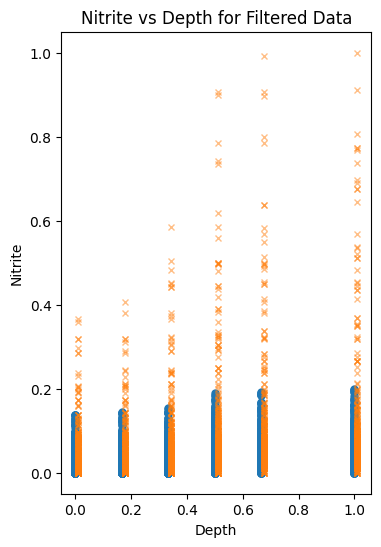

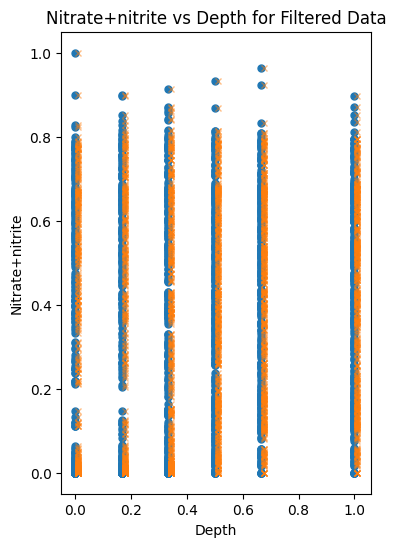

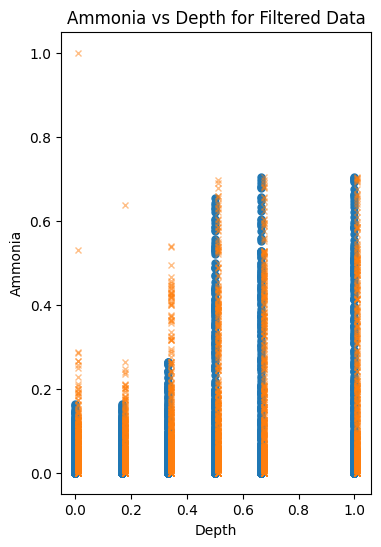

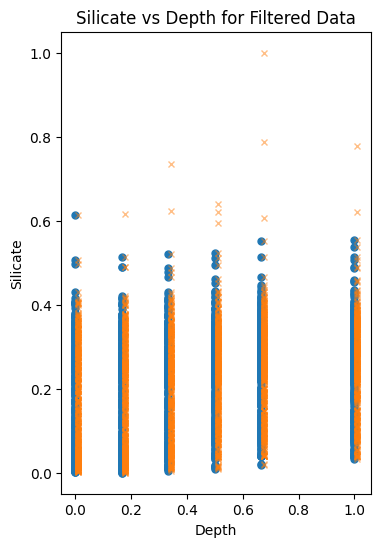

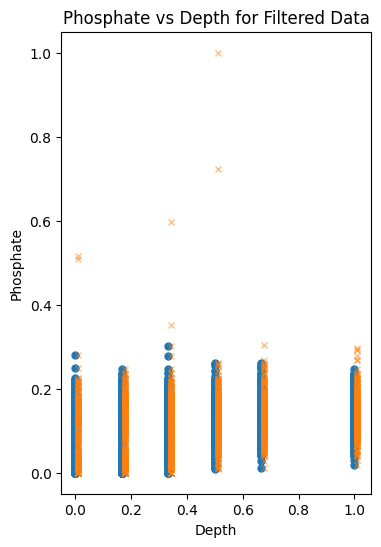

In [100]:
for column in df.columns[1:]:
    plt.figure(figsize=(4, 6))
    plt.plot(df_filtered['Depth'], df_filtered[column], 'o', markersize=5, label='Filtered')
    plt.plot(df_scaled['Depth']+0.01, df_scaled[column], 'x', markersize=5, alpha=0.5, label='Scaled')
    plt.xlabel("Depth")
    plt.ylabel(column.capitalize())
    plt.title(f"{column.capitalize()} vs Depth for Filtered Data")
    plt.show()